## Middleware

Middleware providers a way to more tightly control what happens inside the agent. Middleware is useful for the following : 

    . Tracking agent behavior with logging, analytics and debugging.
    . Transforming prompts, tool selection, and output formating.
    . Adding retries, fallbacks, and early termination logic.
    . Applying rate limits, guardrails, and PII detection.

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"]= os.getenv("GROQ_API_KEY")
from langchain_groq import ChatGroq
model= ChatGroq(model= "qwen/qwen3.6-27b")


## Summarization MiddleWare

Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context. Summarization is useful for the following:

    . Long-running conversation that exceed context windows.
    . multi-turn dialogues with extensive history.
    . Application where preserving full conversation context matters.

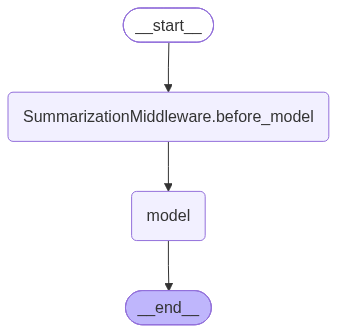

In [4]:
from langchain.agents import create_agent 
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

## agent with Messagebased summerization

agent = create_agent(
    model,
    checkpointer=InMemorySaver(),
    middleware={
        SummarizationMiddleware(
            model,
            trigger=("messages", 10),
            keep=("messages", 4)
        )
    }
)

agent

In [5]:
## thread id

config = {"configurable": {"thread_id": "test1"}}

In [10]:
# Alternate test data

questions = [
    "what is 2+2?",
    "what is 10*5?",
    "what is 100/4?",
    "what is 15-7?",
    "what is 3*3?",
    "what is 4*4?",
]

for q in questions:
    response = agent.invoke({"messages": [HumanMessage(content=q)]}, config)
    print(f"Messages: {response}")
    print(f"Messages: {len(response['messages'])}")
    

Messages: {'messages': [HumanMessage(content='what is 2+2?', additional_kwargs={}, response_metadata={}, id='c802fd1c-5204-47e9-b64d-9b5b1133eaff'), AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:** The user asks "what is 2+2?"\n2.  **Identify Core Task:** This is a basic arithmetic question.\n3.  **Perform Calculation:** 2 + 2 = 4.\n4.  **Formulate Response:** Keep it direct and accurate. "2 + 2 equals 4."\n5.  **Check for Nuance/Traps:** Sometimes users ask simple math questions to test AI, but there\'s no trick here. Just give the straightforward answer.\n6.  **Output Generation:** "2 + 2 equals 4." (or simply "4") I\'ll go with a clear, concise answer.✅\n</think>\n\n2 + 2 equals **4**.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 167, 'prompt_tokens': 17, 'total_tokens': 184, 'completion_time': 0.31796872, 'completion_tokens_details': None, 'prompt_time': 0.000218357, 'prompt_tokens_details': None, 'queue_tim

## Token Size

In [11]:
from langchain_core.tools import tool

@tool  
def search_hotels(city: str)-> str:
    """Search hotels - returns long response to use more tokens."""
    return f"""Hotels in {city}:
    1. Grand Hotel - A luxurious hotel with stunning views of the city skyline. It offers spacious rooms, a rooftop pool, and a world-class spa.
    2. City Inn - A budget-friendly hotel located in the heart of the city. It provides comfortable rooms, free Wi-Fi, and easy access to public transportation.
    3. Riverside Resort - A charming hotel situated along the riverbank. It features cozy rooms, a restaurant with local cuisine, and scenic walking trails."""
    
agent = create_agent(
    model,  
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware={
        SummarizationMiddleware(
            model,
            trigger=("tokens", 550),
            keep=("tokens", 200),
        )
    }
)

config  = {"configurable": {"thread_id": "test-1"}}

# Token counter (approximate)

def count_tokens(messages):
    total_chars =  sum(len(message.content.split()) for message in messages)
    return total_chars//4 # 4 chars = 1 token



In [ ]:
# Run test
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
    {"messages": [HumanMessage(content=f"Find hotels in {city}")]},
    config=config
)
    
    tokens = count_tokens(response["messages"])
    print(f"{city} ~{tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

## Human In the Loop MiddleWare

Pause agent for human approvel, editing, or rejection of tool calls before they excute. Human-inthe-loop is useful for the following:

    . High-stakes operations requiring human approvel(e.g. database writes, financial transactions).
    . Compliance Workflows where human oversight is mandatory.
    . Long-running conversations where human feedback guides the agent.

In [16]:

from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

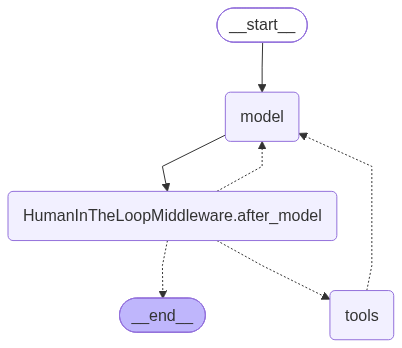

In [18]:
agent=create_agent(
    model,
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions":["approve","edit","reject"]
                },
                "read_email_tool":False,

            }
        )
    ]
)
agent

In [19]:
config = {"configurable": {"thread_id": "test-approve"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [20]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='584e4f12-b840-4e88-9d9a-9305eb04db2f'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Thinking Process:\n1.  **Analyze User Input**: User wants to send an email.\n   - Recipient: `john@test.com`\n   - Subject: `Hello`\n   - Body: `How are you?`\n2.  **Identify Tool**: `send_email_tool` matches the requirement.\n3.  **Check Parameters**:\n   - `recipient`: "john@test.com" (required)\n   - `subject`: "Hello" (required)\n   - `body`: "How are you?" (required)\n   All required parameters are provided.\n4.  **Execute Tool**: Call `send_email_tool` with the specified parameters.\n5.  **Formulate Response**: Return the result of the tool call. Keep it concise.✅\n', 'tool_calls': [{'id': '06h6qcnjq', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_t

In [21]:

from langgraph.types import Command
# Step 2: Approve
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "approve"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: The email has been sent to john@test.com with the subject 'Hello'.


## Reject

In [22]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver


def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model,
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "read_email_tool": False,
            }
        ),
    ],
)

In [23]:
config = {"configurable": {"thread_id": "test-reject"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config)

In [24]:
# Step 2: Reject
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "reject"}
                ]
            }
        ),
        config=config
    )
    

⏸️ Paused! Approving...


In [25]:

result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='f50ddfee-5a9e-49d6-b8c5-46231962705a'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user wants to send an email.\nI need to use the `send_email_tool` function.\nThe parameters for this function are:\n- `recipient`: "john@test.com"\n- `subject`: "Hello"\n- `body`: "How are you?"\n\nAll required parameters are provided. I will proceed with the function call.\n', 'tool_calls': [{'id': 'dkmvvh5a8', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 132, 'prompt_tokens': 374, 'total_tokens': 506, 'completion_time': 0.25899751, 'completion_tokens_details': {'reasoning_tokens': 73}, 'prompt_time': 0.028105889, 'prompt_tokens_details': None, 'queue_time': 0.049

## Editing

In [26]:

from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver


def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model,
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "read_email_tool": False,
            }
        ),
    ],
)

In [27]:
config = {"configurable": {"thread_id": "test-edit"}}

# Step 1: Request (with wrong info)
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'")]},
    config=config
)

In [28]:

result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='c556be33-bef8-41a6-b301-75545eb650b7'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Thinking Process:\n1.  Analyze User Input: User wants to send an email.\n   - Recipient: wrong@email.com\n   - Subject: Test\n   - Body: Hello\n2.  Identify Tool: `send_email_tool` matches the request.\n3.  Check Parameters:\n   - `recipient`: "wrong@email.com"\n   - `subject`: "Test"\n   - `body`: "Hello"\n   All required parameters are provided.\n4.  Execute Tool: Call `send_email_tool` with the specified parameters.\n5.  Formulate Response: Return the result of the tool call.✅\n', 'tool_calls': [{'id': 'xd5baxa6a', 'function': {'arguments': '{"body":"Hello","recipient":"wrong@email.com","subject":"Test"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 192, 'prompt_token

In [29]:
# Step 2: Edit and approve
if "__interrupt__" in result:
    print("⏸️ Paused! Editing...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {
                        "type": "edit",
                        "edited_action": {
                            "name": "send_email_tool",      # Tool name
                            "args": {                   # New arguments
                                "recipient": "correct@email.com",
                                "subject": "Corrected Subject",
                                "body": "This was edited by human before sending"
                            }
                        }
                    }
                ]
            }
        ),
        config=config
    )
    
    print(f"✏️ Result: {result['messages'][-1].content}")

⏸️ Paused! Editing...
✏️ Result: The email was successfully sent to `correct@email.com` with the subject 'Corrected Subject' and the body 'This was edited by human before sending'.
